<a href="https://colab.research.google.com/github/shivampatle2004/Machine-Learning-/blob/main/DecisionTree_shivampatle_cs23186.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Tree

In [9]:

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
path="/content/drive/MyDrive/ml_dataset/BreastCancer.csv"

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Load Data
path = "/content/drive/MyDrive/ml_dataset/BreastCancer.csv"
df = pd.read_csv(path)

# 2. Preprocessing
# Map diagnosis to binary
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
# Drop 'id' and any columns with all NaNs (like 'Unnamed: 32' if present)
df = df.dropna(axis=1, how='all')
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

# 3. Data Splitting
# 70-30 Split
X_train70, X_test70, y_train70, y_test70 = train_test_split(X, y, test_size=0.3, random_state=42)
# 80-20 Split
X_train80, X_test80, y_train80, y_test80 = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and split successfully.")

Data loaded and split successfully.


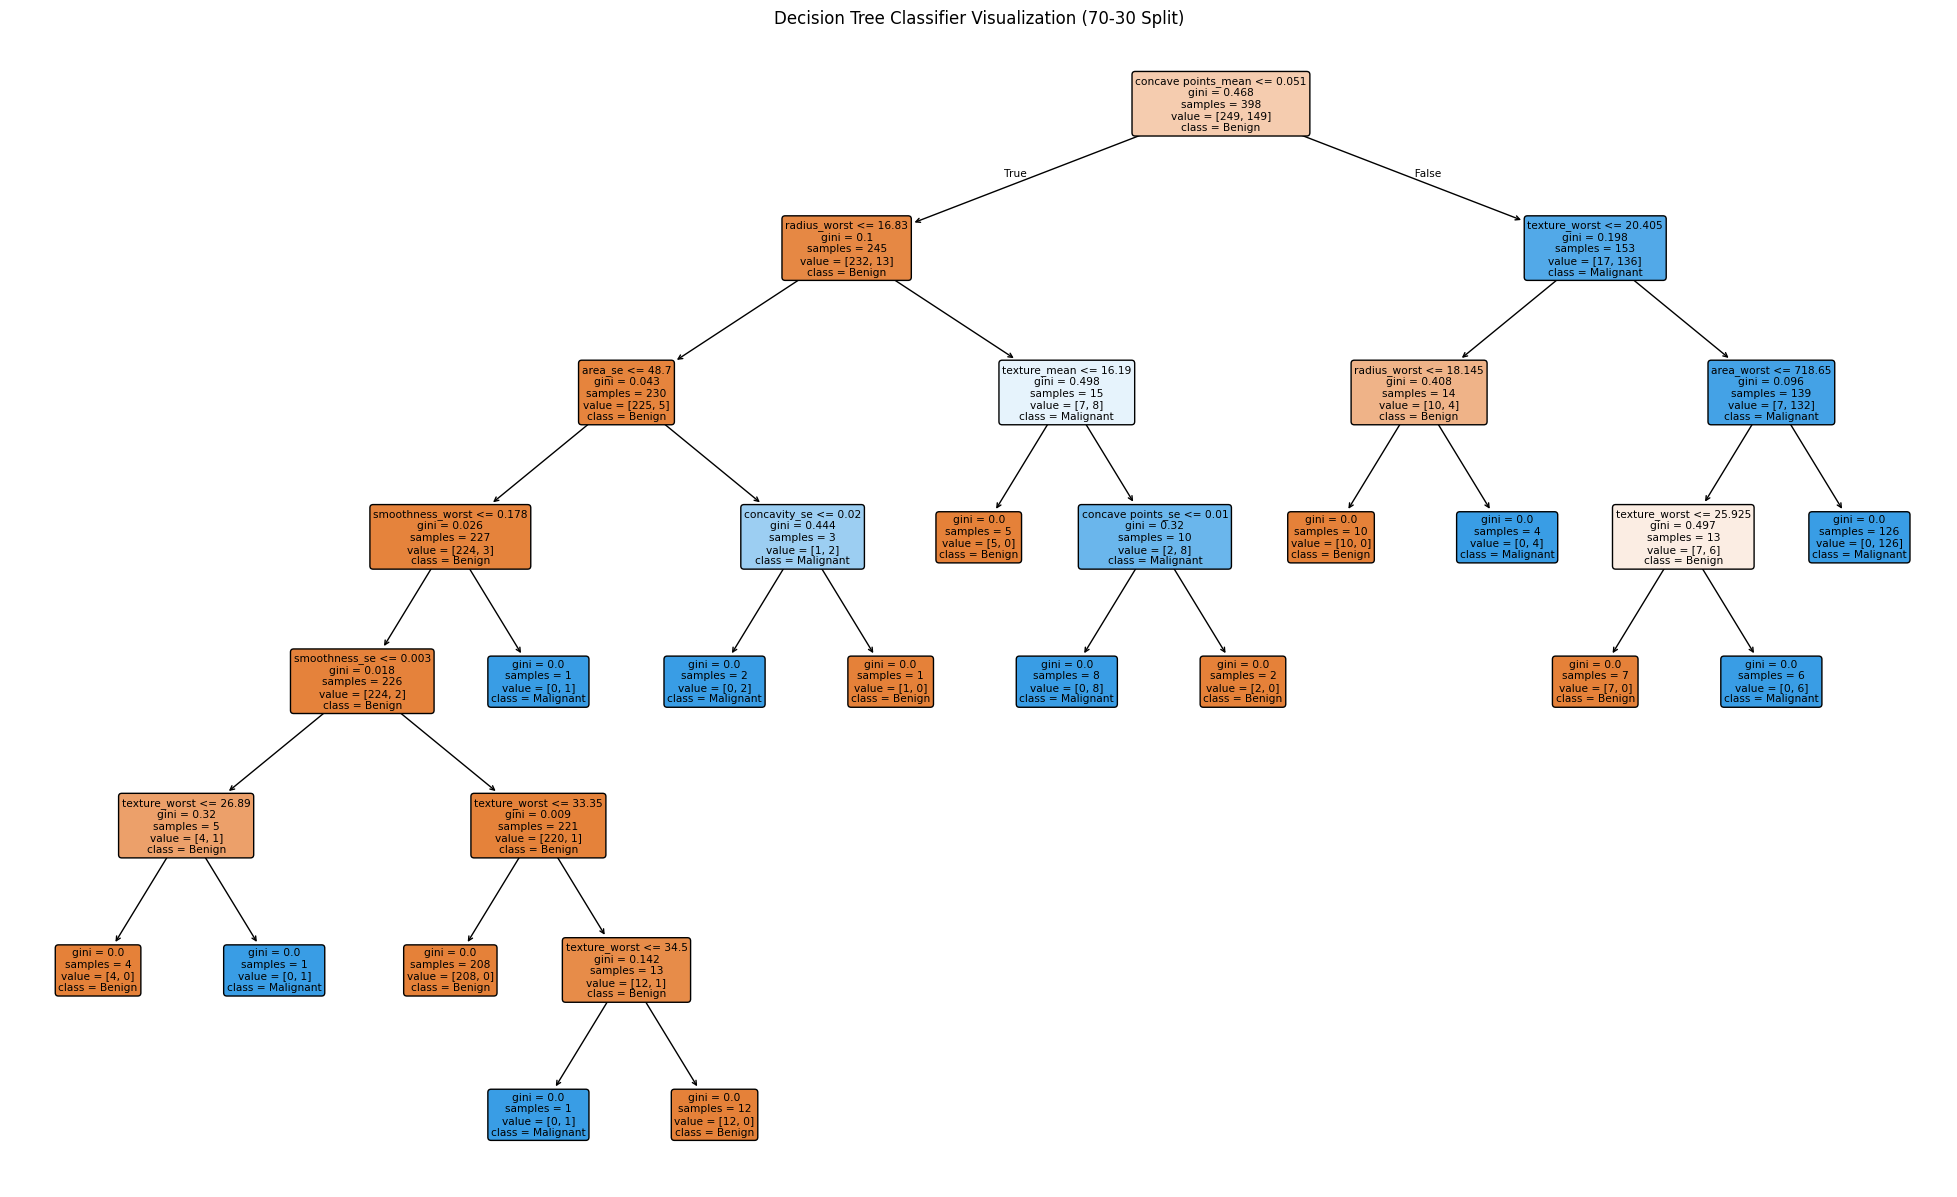

In [28]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualizing the 70-30 split model (dtree_70)
plt.figure(figsize=(25, 15))
plot_tree(dtree_70, filled=True, feature_names=X.columns.tolist(), class_names=['Benign', 'Malignant'], rounded=True)
plt.title("Decision Tree Classifier Visualization (70-30 Split)")
plt.show()

In [31]:
from sklearn.tree import DecisionTreeClassifier

# Ensure we use the cleaned 70-30 split data from cell eabf15eb
# Initialize the Decision Tree Classifier
dtree_70 = DecisionTreeClassifier(random_state=42)

# Train the model using the 70-30 training set
dtree_70.fit(X_train70, y_train70)

print("Decision Tree Classifier (70-30 split) trained successfully without NaNs.")

Decision Tree Classifier (70-30 split) trained successfully without NaNs.


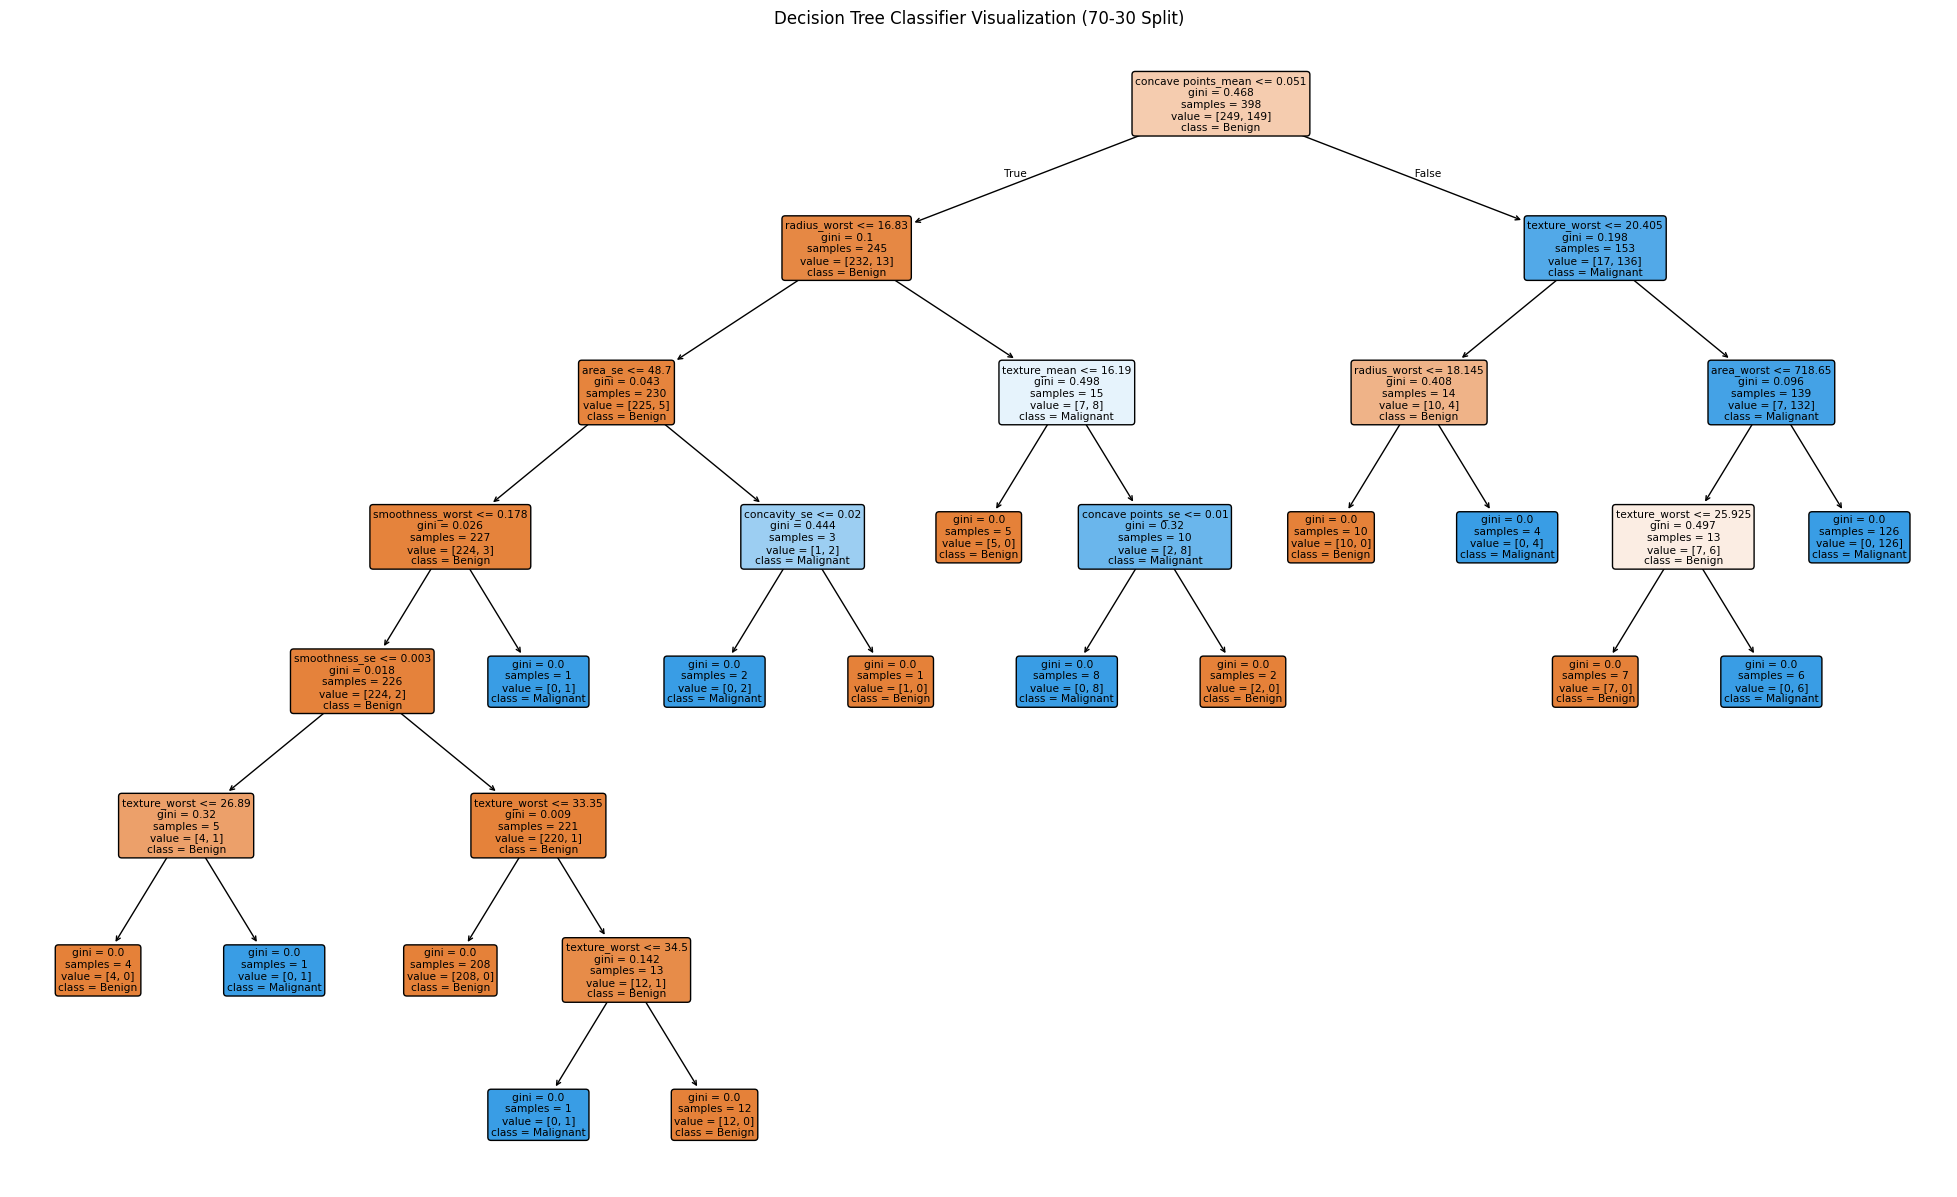

In [32]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualizing the fitted dtree_70 model
plt.figure(figsize=(25, 15))
plot_tree(dtree_70, filled=True, feature_names=X.columns.tolist(), class_names=['Benign', 'Malignant'], rounded=True)
plt.title("Decision Tree Classifier Visualization (70-30 Split)")
plt.show()

### Data Preparation for Decision Tree

In [22]:
# Encode the target variable 'diagnosis'
# 'M' for Malignant will be 1, 'B' for Benign will be 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Drop the 'id' column as it's not a feature for classification
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
display(X.head())

Features (X) shape: (569, 30)
Target (y) shape: (569,)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Split Data into Training and Testing Sets

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (398, 30)
X_test shape: (171, 30)
y_train shape: (398,)
y_test shape: (171,)


### Train the Decision Tree Classifier

In [24]:
# 4. Train Models

# Model for 70-30 split
dtree_70 = DecisionTreeClassifier(random_state=42)
dtree_70.fit(X_train70, y_train70)

# Model for 80-20 split
dtree_80 = DecisionTreeClassifier(random_state=42)
dtree_80.fit(X_train80, y_train80)

print("Both Decision Tree models trained successfully.")

Both Decision Tree models trained successfully.


### Evaluate the Model

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions using the correctly trained 70-30 model
y_pred = dtree_70.predict(X_test70)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test70, y_pred)
precision = precision_score(y_test70, y_pred)
recall = recall_score(y_test70, y_pred)
f1 = f1_score(y_test70, y_pred)
conf_matrix = confusion_matrix(y_test70, y_pred)

print(f"Accuracy (70-30): {accuracy:.4f}")
print(f"Precision (70-30): {precision:.4f}")
print(f"Recall (70-30): {recall:.4f}")
print(f"F1-Score (70-30): {f1:.4f}")
print("Confusion Matrix:\n", conf_matrix)

Accuracy (70-30): 0.9415
Precision (70-30): 0.8955
Recall (70-30): 0.9524
F1-Score (70-30): 0.9231
Confusion Matrix:
 [[101   7]
 [  3  60]]


## Split Data (80-20)

### Subtask:
Split the dataset into training and testing sets using an 80% training and 20% testing ratio.


In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Re-define path if it's not globally available (from 7NzDVklqhVdx)
path = "/content/drive/MyDrive/ml_dataset/BreastCancer.csv"

# Re-load df if it's not globally available (from eabf15eb)
df = pd.read_csv(path)

# Re-encode the target variable 'diagnosis' and define X, y (from 0f6b7189)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train_80 shape:", X_train_80.shape)
print("X_test_80 shape:", X_test_80.shape)
print("y_train_80 shape:", y_train_80.shape)
print("y_test_80 shape:", y_test_80.shape)

X_train_80 shape: (455, 31)
X_test_80 shape: (114, 31)
y_train_80 shape: (455,)
y_test_80 shape: (114,)


**Reasoning**:
The user wants to train a Decision Tree Classifier using the training data from the 80-20 split. This involves importing the necessary class, initializing the model with a specified random state, and then fitting the model to the training data.



In [38]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier for 80-20 split
dtree_80 = DecisionTreeClassifier(random_state=42)

# Train the model
dtree_80.fit(X_train_80, y_train_80)

print("Decision Tree Classifier (80-20 split) trained successfully.")

Decision Tree Classifier (80-20 split) trained successfully.


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set from the 80-20 split
y_pred_80 = dtree_80.predict(X_test_80)

# Calculate evaluation metrics for the 80-20 split
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
precision_80 = precision_score(y_test_80, y_pred_80)
recall_80 = recall_score(y_test_80, y_pred_80)
f1_80 = f1_score(y_test_80, y_pred_80)
conf_matrix_80 = confusion_matrix(y_test_80, y_pred_80)

print(f"Accuracy (80-20 split): {accuracy_80:.4f}")
print(f"Precision (80-20 split): {precision_80:.4f}")
print(f"Recall (80-20 split): {recall_80:.4f}")
print(f"F1-Score (80-20 split): {f1_80:.4f}")
print("Confusion Matrix (80-20 split):\n", conf_matrix_80)


Accuracy (80-20 split): 0.9298
Precision (80-20 split): 0.9070
Recall (80-20 split): 0.9070
F1-Score (80-20 split): 0.9070
Confusion Matrix (80-20 split):
 [[67  4]
 [ 4 39]]


## Split Data (70-30)

### Subtask:
Ensure the dataset is split into training and testing sets using a 70% training and 30% testing ratio. This step will re-execute the existing data splitting to ensure variables like `X_train`, `X_test`, `y_train`, and `y_test` are correctly defined for the 70-30 split.


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (398, 31)
X_test shape: (171, 31)
y_train shape: (398,)
y_test shape: (171,)


In [ ]:
from google.colab import output
# This programmatically clears the output of the cell execution
output.clear()

## Train Decision Tree (70-30 Split)

### Subtask:
Train a Decision Tree Classifier using the training data from the 70-30 split (`X_train`, `y_train`). This step will initialize and fit the model, making it ready for evaluation.


In [41]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier for 70-30 split
dtree_70 = DecisionTreeClassifier(random_state=42)

# Train the model
dtree_70.fit(X_train, y_train)

print("Decision Tree Classifier (70-30 split) trained successfully.")

Decision Tree Classifier (70-30 split) trained successfully.


In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set from the 70-30 split
y_pred_70 = dtree_70.predict(X_test)

# Calculate evaluation metrics for the 70-30 split
accuracy_70 = accuracy_score(y_test, y_pred_70)
precision_70 = precision_score(y_test, y_pred_70)
recall_70 = recall_score(y_test, y_pred_70)
f1_70 = f1_score(y_test, y_pred_70)
conf_matrix_70 = confusion_matrix(y_test, y_pred_70)

print(f"Accuracy (70-30 split): {accuracy_70:.4f}")
print(f"Precision (70-30 split): {precision_70:.4f}")
print(f"Recall (70-30 split): {recall_70:.4f}")
print(f"F1-Score (70-30 split): {f1_70:.4f}")
print("Confusion Matrix (70-30 split):\n", conf_matrix_70)


Accuracy (70-30 split): 0.9357
Precision (70-30 split): 0.8824
Recall (70-30 split): 0.9524
F1-Score (70-30 split): 0.9160
Confusion Matrix (70-30 split):
 [[100   8]
 [  3  60]]


In [44]:
# 5. Evaluation and Comparison

def get_metrics(model, X_test, y_test):
    # Ensure feature names match by aligning X_test columns to model expectations if necessary
    y_pred = model.predict(X_test)
    return [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]

# Using the most recently trained models from cells 6aa14d9c and da5a4457
# Note: Ensure the X_test variables used here match the feature count used during .fit()
metrics_70 = get_metrics(dtree_70, X_test, y_test)
metrics_80 = get_metrics(dtree_80, X_test_80, y_test_80)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    '70-30 Split': metrics_70,
    '80-20 Split': metrics_80
})

display(comparison_df)

,Metric,70-30 Split,80-20 Split
0,Accuracy,0.935673,0.929825
1,Precision,0.882353,0.906977
2,Recall,0.952381,0.906977
3,F1-Score,0.916031,0.906977


## Performance Analysis: 70/30 vs 80/20 Split

In this section, we compare the classification performance and the Receiver Operating Characteristic (ROC) curves for our two Decision Tree models.

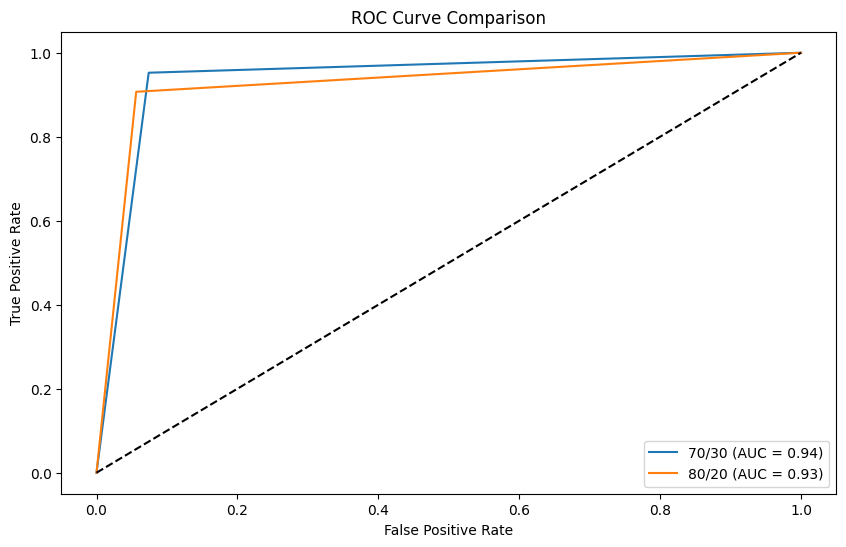

In [47]:
# 6. ROC Curve Visualization

# Ensure we use the same test sets that match the features used in the most recent fit
y_score70 = dtree_70.predict_proba(X_test)[:, 1]
y_score80 = dtree_80.predict_proba(X_test_80)[:, 1]

fpr70, tpr70, _ = roc_curve(y_test, y_score70)
fpr80, tpr80, _ = roc_curve(y_test_80, y_score80)

plt.figure(figsize=(10, 6))
plt.plot(fpr70, tpr70, label=f'70/30 (AUC = {auc(fpr70, tpr70):.2f})')
plt.plot(fpr80, tpr80, label=f'80/20 (AUC = {auc(fpr80, tpr80):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

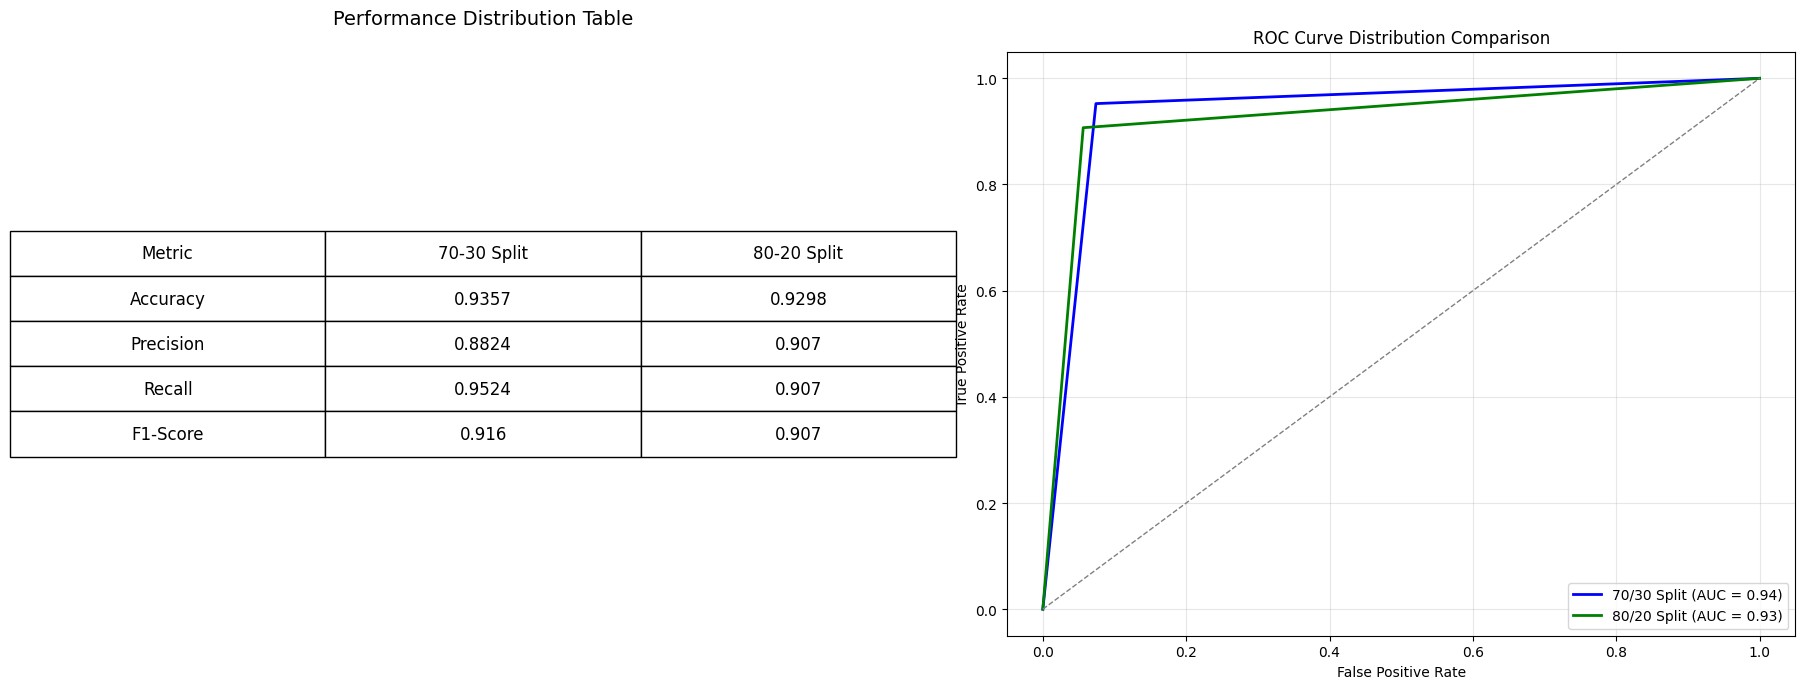

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import auc

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 1. Left Side: Performance Table
ax1.axis('tight')
ax1.axis('off')
ax1.set_title('Performance Distribution Table', fontsize=14, pad=20)

# Format the comparison data
comparison_data = comparison_df.round(4).values
table = ax1.table(cellText=comparison_data,
                  colLabels=comparison_df.columns,
                  loc='center',
                  cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.5)  # Scale for better readability

# 2. Right Side: ROC Curve Comparison
ax2.plot(fpr70, tpr70, color='blue', lw=2, label=f'70/30 Split (AUC = {auc(fpr70, tpr70):.2f})')
ax2.plot(fpr80, tpr80, color='green', lw=2, label=f'80/20 Split (AUC = {auc(fpr80, tpr80):.2f})')
ax2.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve Distribution Comparison')
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

--- Performance Distribution Table (70/30 vs 80/20) ---


,Metric,70-30 Split,80-20 Split
0,Accuracy,0.935673,0.929825
1,Precision,0.882353,0.906977
2,Recall,0.952381,0.906977
3,F1-Score,0.916031,0.906977


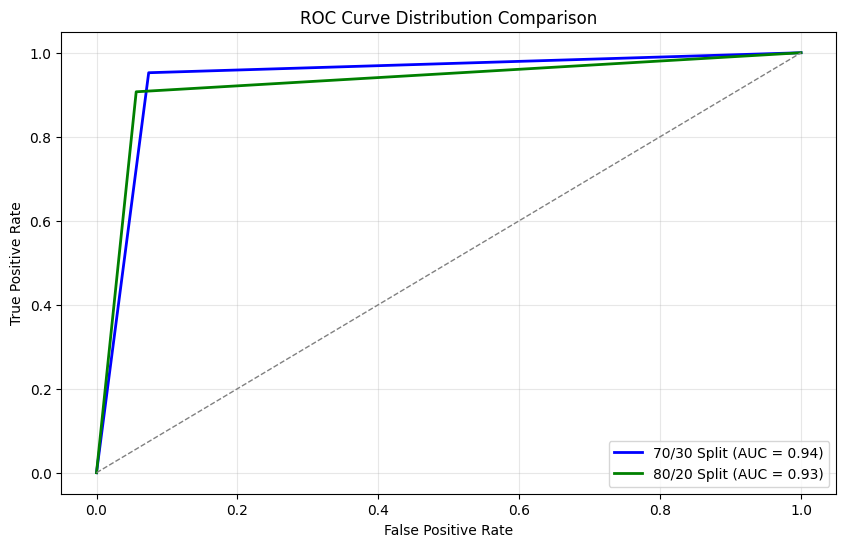

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc

# 1. Display the Distribution Table
# metrics_70 and metrics_80 are already in your kernel from cell 871f1ae8
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    '70-30 Split': metrics_70,
    '80-20 Split': metrics_80
})

print("--- Performance Distribution Table (70/30 vs 80/20) ---")
display(comparison_df)

# 2. Display the ROC Graph
# fpr and tpr values are already in your kernel from cell dcaf27b6
plt.figure(figsize=(10, 6))
plt.plot(fpr70, tpr70, color='blue', lw=2, label=f'70/30 Split (AUC = {auc(fpr70, tpr70):.2f})')
plt.plot(fpr80, tpr80, color='green', lw=2, label=f'80/20 Split (AUC = {auc(fpr80, tpr80):.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Distribution Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()